INTRODUCTION:

This assignment focuses on the simulation and analysis of indoor wireless signal propagation using Python. It explores the relationship between signal strength, spatial positioning, and receiver similarity within a defined 3D environment. By modeling a wireless scenario at a carrier frequency of 5.8 GHz, the assignment applies core concepts such as Free-Space Path Loss (FSPL) and Reference Signal Received Power (RSRP) to evaluate how signals behave in an indoor setting.

Through a step-by-step approach, the simulation defines room dimensions, calculates received power at various receiver locations, and visualizes results using normalized RSRP bar charts. Further analysis includes computing Euclidean distances in RSRP feature space and comparing them to physical distances, providing insights into how closely signal patterns reflect spatial proximity. This comparison is especially relevant for indoor localization and fingerprinting techniques, where signal similarity is leveraged to estimate positions.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.metrics import confusion_matrix


We define the room size, transmitter frequency, antenna power, and other simulation constants.

This step establishes the foundational parameters of the wireless communication scenario, including the carrier frequency (5.8 G`sHz), the speed of light, and the resulting wavelength. It also defines the 3D physical dimensions of the room, setting the scene for spatial analysis of signal propagation. The transmit power in dBm is set, which is critical for calculating received signal strength in subsequent steps.

In [ ]:
# ---- Step 1: Constants and Room Dimensions
fc = 5.8e9              # Carrier frequency in Hz (5.8 GHz)
c = 3e8                 # Speed of light in m/s
lambda_ = c / fc        # Wavelength in meters
room_size = np.array([5, 8, 2])  # Room dimensions (X=5m, Y=8m, Z=2m)
tx_power_dBm = 30       # Transmit power in dBm

Four transmitters are placed at fixed coordinates near the ceiling (1.9 m height).


In [ ]:
# ---- Step 2: Transmitter locations (4 transmitters)
tx_locs = np.array([
    [0.2, 0.2, 1.9],
    [0.2, 7.8, 1.9],
    [4.8, 4.0, 1.9],
    [4.8, 1.0, 1.9]
])

The training receivers are placed in a structured grid pattern within the room. Each Rx is placed at 0.9 m height (user level).

In [ ]:
# ---- Step 3: Training receiver setup (2x4 grid)
grid_x = np.linspace(0.55, 4.45, 2)
grid_y = np.linspace(0.25, 7.75, 4)
rx_x_grid, rx_y_grid = np.meshgrid(grid_x, grid_y)
rx_x = rx_x_grid.flatten()
rx_y = rx_y_grid.flatten()
rx_z = 0.9 * np.ones_like(rx_x)
rxs_train = np.stack([rx_x, rx_y, rx_z], axis=1)


Randomly place 20 test receivers inside the room for validation. These represent unknown user locations.

In [ ]:
# ---- Step 4: Random test receiver setup
np.random.seed(0)
num_test = 20
rx_test_x = room_size[0] * np.random.rand(num_test)
rx_test_y = room_size[1] * np.random.rand(num_test)
rx_test_z = 0.9 * np.ones(num_test)
rxs_test = np.stack([rx_test_x, rx_test_y, rx_test_z], axis=1)


We simulate the Received Signal Received Power (RSRP) using the Free Space Path Loss (FSPL) model.

RSRP values are normalized to the range
[
0
,
1
]
[0,1] to standardize input features. Here, the Free-Space Path Loss (FSPL) model is applied to compute the Reference Signal Received Power (RSRP) at each receiver. The model calculates path loss based on distance and frequency and then translates it into received power using the known transmit power. This is essential in wireless communication to understand how signal strength degrades over distance and how this affects link quality.

In [ ]:
# ---- Step 5: Compute RSRP based on FSPL model
def compute_rsrp(tx, rx):
    dist = cdist(tx, rx)
    path_loss_dB = 20 * np.log10(dist) + 20 * np.log10(fc) - 147.55
    rsrp = 10 ** ((tx_power_dBm - path_loss_dB) / 10)
    return rsrp

RSRP_train = compute_rsrp(tx_locs, rxs_train)
RSRP_test = compute_rsrp(tx_locs, rxs_test)

# Normalize RSRP values
def normalize_rsrp(RSRP):
    return (RSRP - np.min(RSRP)) / (np.max(RSRP) - np.min(RSRP))

normalized_rsrp_train = normalize_rsrp(RSRP_train)
normalized_rsrp_test = normalize_rsrp(RSRP_test)

In this step, normalized RSRP values are visualized for each training receiver across all transmitters. The normalization scales the power values between 0 and 1 for comparability. This bar chart helps illustrate the relative received signal strength across different transmitter-receiver pairs, aiding in performance evaluation and transmitter placement strategies.

In [ ]:
# ---- Step 6: RSRP bar chart for training Rx
plt.figure()
bar_data = normalized_rsrp_train.T
x = np.arange(1, bar_data.shape[0] + 1)
for i in range(bar_data.shape[1]):
    plt.bar(x - 0.2 + i*0.1, bar_data[:, i], width=0.1, label=f'Tx{i+1}')
plt.xlabel('Training Receiver Index')
plt.ylabel('Normalized RSRP')
plt.title('Normalized RSRP for 8 Training Receivers')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()


We calculate the Euclidean distance between each test receiver and all training receivers based on their normalized RSRP vectors.

In this code, the Euclidean distance measures how different the normalized RSRP (Received Signal Received Power) values are between two receiver locations. For each pair of receivers, the code compares their RSRP vectors across all transmitters and computes the distance between them in this "fingerprint space." A smaller Euclidean distance means the signal patterns at those locations are more similar, indicating that the receivers likely experience similar radio environments.

For each test receiver, calculate Euclidean distance between its normalized RSRP vector and every training receiver’s RSRP vector:

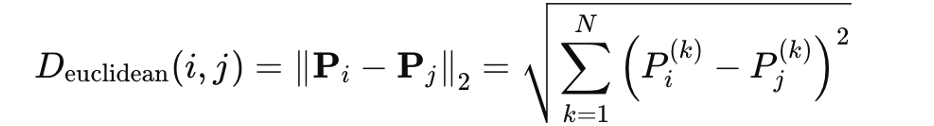

Pi and Pj are normalized RSRP vectors at receiver sites i and j, respectively.

Pi(k): normalized RSRP from transmitter k at receiver i.

N: number of transmitters

In [ ]:
# ---- Step 7: Euclidean distance in RSRP space
euclidean_dist = cdist(normalized_rsrp_test.T, normalized_rsrp_train.T)


This step visualizes the Euclidean distance between selected test receivers and all training receivers based on RSRP features. By plotting these distances, the step aims to explore the similarity in received signal patterns between different receiver locations, which is key in tasks like fingerprinting-based indoor positioning.

In [ ]:
# ---- Step 8: Plot distance profiles for test receivers
selected_idx = [0, 9, 19]
for idx in selected_idx:
    plt.figure()
    plt.plot(range(1, 9), euclidean_dist[idx], 'o-b')
    plt.xlabel('Training Receiver Index')
    plt.ylabel('Euclidean Distance')
    plt.title(f'Euclidean Distance from Test Receiver {idx+1} to Training Receivers')
    plt.grid(True)
    plt.xticks(range(1, 9))
    plt.show()


Compares signal similarity (Euclidean) and spatial proximity (physical distance) among R1, R2, and R3.

The Cartesian (Euclidean) distance formula is used to compute the physical separation between receiver locations in 3D space. Based on the receiver coordinates defined in the code (Rx_x, Rx_y and Rx_z), the distance between any two receivers is calculated as:

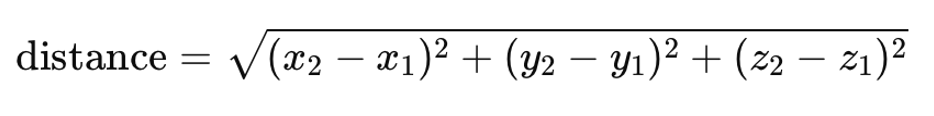

This calculation is implemented to compare the true spatial distance between reference receivers (R1–R3) and all other training receivers.

This part compares the Euclidean distances in RSRP feature space to actual physical distances between receivers. The goal is to examine the correlation between signal similarity and spatial proximity, which is fundamental for determining the feasibility and accuracy of location estimation techniques based on signal characteristics.



In [ ]:
# ---- Step 9: Euclidean vs physical distance
euclidean_R = []
physical_R = []
for i in range(3):  # R1 to R3
    euc_row = []
    phy_row = []
    for j in range(8):
        if i == j:
            continue
        euc = np.linalg.norm(normalized_rsrp_train[:, i] - normalized_rsrp_train[:, j])
        phy = np.linalg.norm(rxs_train[i] - rxs_train[j])
        euc_row.append(euc)
        phy_row.append(phy)
    euclidean_R.append(euc_row)
    physical_R.append(phy_row)

# Plot comparison
for r in range(3):
    plt.figure()
    indices = list(range(8))
    indices.pop(r)
    plt.plot(indices, euclidean_R[r], 'bo-', label='Euclidean Distance')
    plt.plot(indices, physical_R[r], 'ro-', label='Physical Distance')
    plt.xlabel('Receiver Index')
    plt.title(f'Distance Comparison for Receiver R{r+1}')
    plt.legend()
    plt.grid(True)
    plt.xticks(indices)
    plt.show()


These are some differents coordinates of transmitters than can be used. The goal is to see how they affect the RSRP since they play an important role on it.

In [ ]:
# Transmitter locations (4 transmitters)
tx_locs = np.array([
    [0.2, 0.2, 1.0],
    [0.2, 7.8, 1.5],
    [4.8, 4.0, 1.0],
    [4.8, 1.0, 1.5]
])

In [ ]:
# Transmitter locations (4 transmitters)
tx_locs = np.array([
    [1.7, 0.9, 1.8],
    [0.2, 7.8, 1.2],
    [4.8, 4.0, 1.0],
    [3.8, 1.0, 1.5]
])